# Full Pipeline — Customers + Accounts + Transactions

This notebook runs the complete synthetic data generation pipeline in a single shot and produces joined views across all three entities — the same way a data analyst or tester would actually query the data in Snowflake.

**What we cover:**
1. Generate the full dataset
2. Dataset summary
3. Joined view: Accounts enriched with Customer details
4. Joined view: Transactions enriched with Account type and Customer name
5. Customer portfolio summary (accounts + balances per customer)
6. Top customers by total transaction volume
7. Full dataset export (all three entities)

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

from src.generators.customer import generate_customers
from src.generators.accounts import generate_accounts
from src.generators.transactions import generate_transactions
from src.utils.exporters import write_json, write_csv

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Setup complete.')

Setup complete.


## 1. Generate the Full Dataset

One seed, one call per entity. The dependency chain is:
```
generate_customers() → generate_accounts() → generate_transactions()
```
Each step feeds into the next — accounts need customers to link to, transactions need accounts.

In [2]:
SEED = 42

customers    = generate_customers(count=250, seed=SEED)
accounts     = generate_accounts(customers=customers, total_accounts=450, seed=SEED)
transactions = generate_transactions(accounts=accounts, total_transactions=7500, seed=SEED)

print(f'✓ Customers    : {len(customers):,}')
print(f'✓ Accounts     : {len(accounts):,}')
print(f'✓ Transactions : {len(transactions):,}')

✓ Customers    : 250
✓ Accounts     : 450
✓ Transactions : 7,500


## 2. Dataset Summary

High-level numbers across the full dataset before we start joining.

In [3]:
# Build base DataFrames
customers_df = pd.DataFrame([c.model_dump() for c in customers])
accounts_df  = pd.DataFrame([a.model_dump() for a in accounts])
txn_df       = pd.DataFrame([t.model_dump() for t in transactions])

# Flatten nested address in customers
customers_df = pd.concat([
    customers_df.drop(columns=['address']),
    customers_df['address'].apply(pd.Series).add_prefix('address_')
], axis=1)

print('=== Dataset Summary ===')
print(f'Customers         : {len(customers_df):,}')
print(f'Accounts          : {len(accounts_df):,}')
print(f'  Checking        : {(accounts_df.account_type == "Checking").sum():,}')
print(f'  Savings         : {(accounts_df.account_type == "Savings").sum():,}')
print(f'  CD              : {(accounts_df.account_type == "CD").sum():,}')
print(f'Transactions      : {len(txn_df):,}')
print(f'  Debits          : {(txn_df.transaction_type == "Debit").sum():,}')
print(f'  Credits         : {(txn_df.transaction_type == "Credit").sum():,}')
print(f'Total $ transacted: ${txn_df.amount.sum():,.2f}')
print(f'Total $ on deposit: ${accounts_df.balance.sum():,.2f}')

=== Dataset Summary ===
Customers         : 250
Accounts          : 450
  Checking        : 345
  Savings         : 71
  CD              : 34
Transactions      : 7,500
  Debits          : 3,993
  Credits         : 3,507
Total $ transacted: $14,804,353.41
Total $ on deposit: $5,934,022.78


## 3. Joined View — Accounts + Customer Details

Join accounts to their owning customer on `customer_id`. This is the view a system admin would use to see which customer owns each account — equivalent to a `LEFT JOIN` in Snowflake.

In [4]:
accounts_with_customer = accounts_df.merge(
    customers_df[['customer_id', 'first_name', 'last_name', 'employment_status', 'annual_income', 'address_state']],
    on='customer_id',
    how='left'
)

accounts_with_customer['full_name'] = accounts_with_customer['first_name'] + ' ' + accounts_with_customer['last_name']

display_cols = ['account_id', 'full_name', 'account_type', 'balance', 'interest_rate', 'employment_status', 'annual_income', 'address_state']
print(f'Accounts + Customer joined view: {len(accounts_with_customer):,} rows')
accounts_with_customer[display_cols].head(10)

Accounts + Customer joined view: 450 rows


,account_id,full_name,account_type,balance,interest_rate,employment_status,annual_income,address_state
0,ACT-000001,Danielle Johnson,Checking,3862.15,0.0002,Employed,33500.0,NC
1,ACT-000002,Lisa Smith,Checking,689.51,0.0030,Employed,128000.0,NY
2,ACT-000003,Chad Stanley,Checking,8528.36,0.0026,Employed,43500.0,WI
3,ACT-000004,Brian Underwood,Checking,12189.10,0.0023,Self-Employed,150500.0,IN
4,ACT-000005,Laura Henderson,Checking,4348.60,0.0035,Student,5500.0,TX
5,ACT-000006,Amber Osborne,Checking,1676.57,0.0006,Unemployed,5000.0,WV
6,ACT-000007,Rodney Lewis,Checking,11013.54,0.0031,Employed,85000.0,CA
7,ACT-000008,Joshua Washington,Checking,1412.30,0.0049,Retired,67500.0,MN
8,ACT-000009,Robert Ramirez,Checking,4518.47,0.0033,Employed,110000.0,OR
9,ACT-000010,Bruce Edwards,Checking,12553.13,0.0015,Self-Employed,148500.0,NE


## 4. Joined View — Transactions + Account Type + Customer Name

The richest joined view — every transaction enriched with who owns it and what kind of account it's on. This is what a tester would typically need to verify the UI is displaying transactions correctly.

In [5]:
full_view = txn_df.merge(
    accounts_df[['account_id', 'account_type', 'account_number']],
    on='account_id',
    how='left'
).merge(
    customers_df[['customer_id', 'first_name', 'last_name']],
    on='customer_id',
    how='left'
)

full_view['full_name'] = full_view['first_name'] + ' ' + full_view['last_name']

display_cols = ['transaction_id', 'full_name', 'account_type', 'account_number',
                'transaction_date', 'transaction_code', 'amount', 'running_balance', 'description']

print(f'Full joined view: {len(full_view):,} rows')
full_view[display_cols].head(10)

Full joined view: 7,500 rows


,transaction_id,full_name,account_type,account_number,transaction_date,transaction_code,amount,running_balance,description
0,TXN-0000001,Danielle Johnson,Checking,3746317213,2025-05-22,BILL_PAY,1470.28,2391.87,BILL PAY - Property Management LLC
1,TXN-0000002,Danielle Johnson,Checking,3746317213,2025-06-04,MOBILE_DEPOSIT,750.59,3142.46,MOBILE CHECK DEPOSIT
2,TXN-0000003,Danielle Johnson,Checking,3746317213,2025-06-18,ACH_DEBIT,1098.77,2043.69,ACH DEBIT
3,TXN-0000004,Danielle Johnson,Checking,3746317213,2025-06-22,DIRECT_DEPOSIT,6801.90,8845.59,PAYROLL DIRECT DEPOSIT
4,TXN-0000005,Danielle Johnson,Checking,3746317213,2025-06-24,PURCHASE,57.49,8788.10,POS PURCHASE - Prime Fuel
5,TXN-0000006,Danielle Johnson,Checking,3746317213,2025-06-24,ATM_WITHDRAWAL,135.58,8652.52,ATM WITHDRAWAL - 7213
6,TXN-0000007,Danielle Johnson,Checking,3746317213,2025-09-08,TRANSFER_OUT,5383.34,3269.18,TRANSFER TO 7213
7,TXN-0000008,Danielle Johnson,Checking,3746317213,2025-09-13,PURCHASE,130.20,3138.98,POS PURCHASE - Sunrise Coffee
8,TXN-0000009,Danielle Johnson,Checking,3746317213,2025-09-17,DIRECT_DEPOSIT,4214.45,7353.43,PAYROLL DIRECT DEPOSIT
9,TXN-0000010,Danielle Johnson,Checking,3746317213,2025-10-08,PURCHASE,99.55,7253.88,POS PURCHASE - ValueMart


## 5. Customer Portfolio Summary

Roll up to the customer level — how many accounts does each customer hold and what is their total balance across all accounts? Sorted by total balance descending.

In [6]:
portfolio = accounts_with_customer.groupby(['customer_id', 'full_name', 'annual_income']).agg(
    total_accounts=('account_id', 'count'),
    checking_count=('account_type', lambda x: (x == 'Checking').sum()),
    savings_count=('account_type', lambda x: (x == 'Savings').sum()),
    cd_count=('account_type', lambda x: (x == 'CD').sum()),
    total_balance=('balance', 'sum'),
).reset_index().sort_values('total_balance', ascending=False)

print(f'Customer portfolio summary: {len(portfolio):,} customers')
portfolio[['full_name', 'annual_income', 'total_accounts', 'checking_count', 'savings_count', 'cd_count', 'total_balance']].head(15)

Customer portfolio summary: 250 customers


,full_name,annual_income,total_accounts,checking_count,savings_count,cd_count,total_balance
234,Diana Buchanan,29000.0,5,2,2,1,149873.35
154,Kayla Lewis,13000.0,5,3,1,1,149379.51
230,Kenneth Holland,7000.0,5,1,2,2,131229.56
68,Marcia Hanson,60000.0,2,1,0,1,109825.20
97,Emily Edwards,171000.0,5,1,2,2,97780.42
229,Mary Ramirez,154500.0,2,1,0,1,93840.73
131,Jorge Carter,45500.0,2,1,0,1,91544.44
115,Patrick Barnes,10500.0,5,2,3,0,90343.45
172,Robert White,13000.0,2,1,0,1,86481.60
74,Sara Mcdowell,4000.0,2,1,0,1,85072.43


### Portfolio Balance Distribution

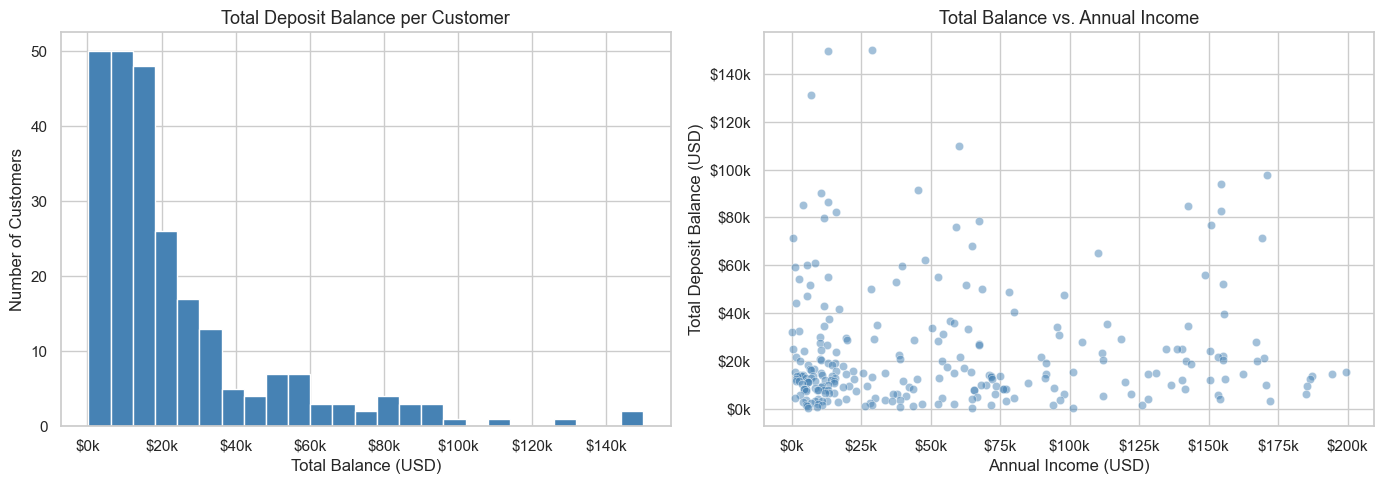

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(portfolio['total_balance'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Total Deposit Balance per Customer', fontsize=13)
axes[0].set_xlabel('Total Balance (USD)')
axes[0].set_ylabel('Number of Customers')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

axes[1].scatter(portfolio['annual_income'], portfolio['total_balance'],
                alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.5)
axes[1].set_title('Total Balance vs. Annual Income', fontsize=13)
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Total Deposit Balance (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

## 6. Top Customers by Transaction Volume

Which customers have the most transaction activity? Useful for validating that the data looks realistic — high-income employed customers should generally show more activity.

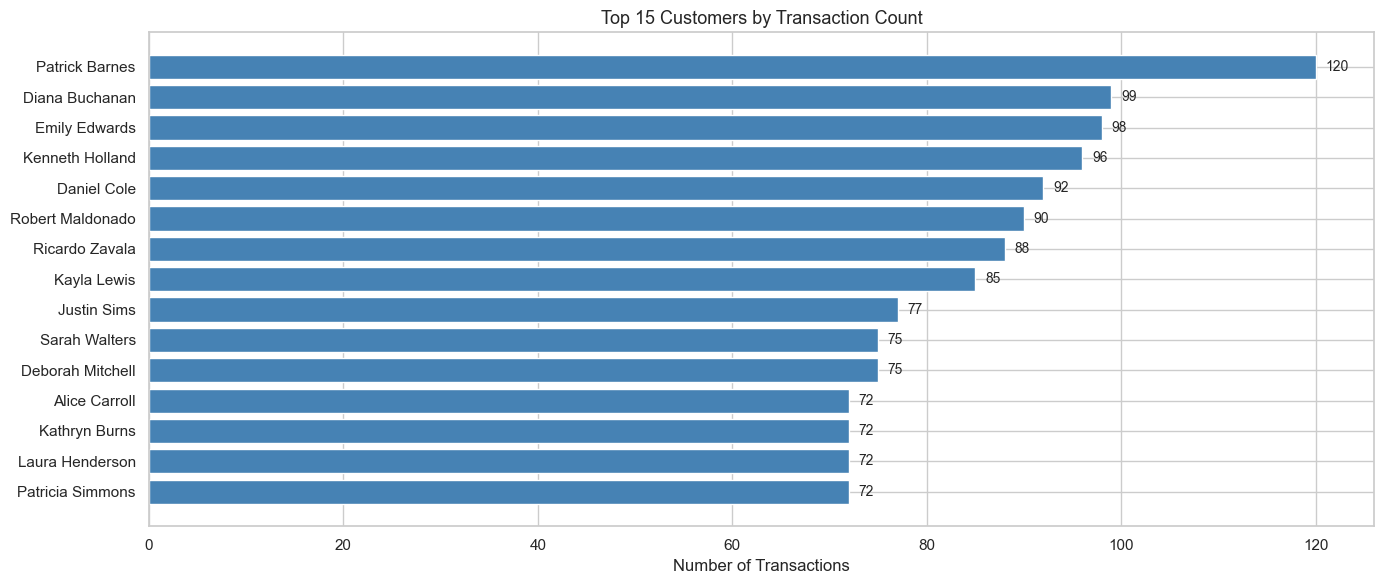

,full_name,txn_count,total_debits,total_credits,total_volume
115,Patrick Barnes,120,158104.55,215876.88,373981.43
234,Diana Buchanan,99,102819.76,100838.50,203658.26
97,Emily Edwards,98,83200.88,154233.62,237434.50
230,Kenneth Holland,96,54277.11,110062.24,164339.35
112,Daniel Cole,92,92193.12,162655.94,254849.06
35,Robert Maldonado,90,83274.63,135102.11,218376.74
14,Ricardo Zavala,88,82258.60,164463.27,246721.87
154,Kayla Lewis,85,38674.11,117012.94,155687.05
173,Justin Sims,77,84804.94,191017.09,275822.03
186,Sarah Walters,75,64539.40,207058.16,271597.56


In [8]:
txn_summary = full_view.groupby(['customer_id', 'full_name']).agg(
    txn_count=('transaction_id', 'count'),
    total_debits=('amount', lambda x: x[full_view.loc[x.index, 'transaction_type'] == 'Debit'].sum()),
    total_credits=('amount', lambda x: x[full_view.loc[x.index, 'transaction_type'] == 'Credit'].sum()),
    total_volume=('amount', 'sum'),
).reset_index().sort_values('txn_count', ascending=False)

top15 = txn_summary.head(15)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top15['full_name'], top15['txn_count'], color='steelblue', edgecolor='white')
ax.set_title('Top 15 Customers by Transaction Count', fontsize=13)
ax.set_xlabel('Number of Transactions')
ax.invert_yaxis()
for bar, count in zip(bars, top15['txn_count']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

top15[['full_name', 'txn_count', 'total_debits', 'total_credits', 'total_volume']].head(10)

## 7. Export — Full Dataset

Write all three entities to `data/outputs/` in both JSON and CSV format, ready for Snowflake loading.

In [9]:
output_dir = Path.cwd().parent / 'data' / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

write_json(customers,    output_dir / 'customers.json')
write_csv(customers,     output_dir / 'customers.csv')

write_json(accounts,     output_dir / 'accounts.json')
write_csv(accounts,      output_dir / 'accounts.csv')

write_json(transactions, output_dir / 'transactions.json')
write_csv(transactions,  output_dir / 'transactions.csv')

print(f'All files written to: {output_dir.resolve()}')
print()
print('  customers.json / customers.csv')
print('  accounts.json  / accounts.csv')
print('  transactions.json / transactions.csv')

All files written to: /Users/gabrielolson/projects/synthetic-data-creation/data/outputs

  customers.json / customers.csv
  accounts.json  / accounts.csv
  transactions.json / transactions.csv
